**📌 Dataset Description**
This dataset contains house sale prices for properties sold in King County, USA (which includes Seattle) between May 2014 and May 2015.

Each row represents a house sale and includes information about the property's price, size, condition, location, and other physical characteristics.

The dataset is suitable for exploratory data analysis (EDA) to understand the main factors affecting house prices.

**Variables Description**
The dataset contains several variables describing different characteristics of houses sold in King County, USA.

The variable id represents a unique identifier assigned to each property.
The variable date indicates the date on which the house was sold.

The target variable in this dataset is price, which represents the sale price of the house and is measured in US Dollars (USD).

The variable bedrooms indicates the number of bedrooms in the house, measured as a count.
Similarly, bathrooms represents the number of bathrooms in the house, also measured as a count.

The variable sqft_living represents the size of the living area, measured in square feet (sq ft).
The variable sqft_lot represents the size of the land area (lot size), also measured in square feet.

The variable floors indicates the number of floors in the house.
The variable waterfront is a binary variable that indicates whether the house has a waterfront view (1 = Yes, 0 = No).
The variable view represents the quality of the view and is measured on a rating scale from 0 to 4.

The variable condition represents the overall condition of the house and is measured on a rating scale from 1 to 5.
The variable grade indicates the overall construction and design quality of the house and is measured on a scale from 1 to 13.

The variable sqft_above represents the square footage of the house above ground level, measured in square feet.
The variable sqft_basement represents the square footage of the basement, also measured in square feet.

The variable yr_built indicates the year the house was originally built.
The variable yr_renovated represents the year the house was renovated. If the value is 0, it means the house has not been renovated.

The variable zipcode represents the ZIP code of the property and is considered a categorical variable related to location.

The variables lat and long represent the geographical coordinates (latitude and longitude) of the property.

Finally, sqft_living15 and sqft_lot15 represent the average living area size and lot size of the nearest 15 neighboring houses, measured in square feet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harlfoxem/housesalesprediction/kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### No. of rows and colomn


In [17]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 21613
Number of columns: 23


### Display all column names

In [3]:
print(df.columns)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


### Data type of columns

In [4]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

### Shape of the DB

In [5]:
df.shape

(21613, 21)

### Converting Date Strings and Extracting Year/Month Features

In [6]:
print(df['date'].head())

df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df[['date','year','month']].head()

0    20141013T000000
1    20141209T000000
2    20150225T000000
3    20141209T000000
4    20150218T000000
Name: date, dtype: object


,date,year,month
0,2014-10-13,2014,10
1,2014-12-09,2014,12
2,2015-02-25,2015,2
3,2014-12-09,2014,12
4,2015-02-18,2015,2


### Data Overview and Structural Summary

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[ns]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   2161

### Top 5 Most Expensive Zip Codes (By Average Price)

In [8]:
df.groupby('zipcode')['price'].mean().sort_values(ascending=False).head()

zipcode
98039    2.160607e+06
98004    1.355927e+06
98040    1.194230e+06
98112    1.095499e+06
98102    9.012583e+05
Name: price, dtype: float64

### Descriptive Statistics and Data Distribution

In [9]:
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,2014-10-29 04:38:01.959931648,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,2014.322954,6.574423
min,1.000102e+06,2014-05-02 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,2014.000000,1.000000
25%,2.123049e+09,2014-07-22 00:00:00,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,2014.000000,4.000000
50%,3.904930e+09,2014-10-16 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,2014.000000,6.000000
75%,7.308900e+09,2015-02-17 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,2015.000000,9.000000
max,9.900000e+09,2015-05-27 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,2015.000000,12.000000
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,0.467616,3.115308


### Checking for Missing Values 

In [10]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
year             0
month            0
dtype: int64

### Checking for Duplicate Records

In [11]:
df.duplicated().sum()

np.int64(0)

### 📈 1. Distribution of House Prices

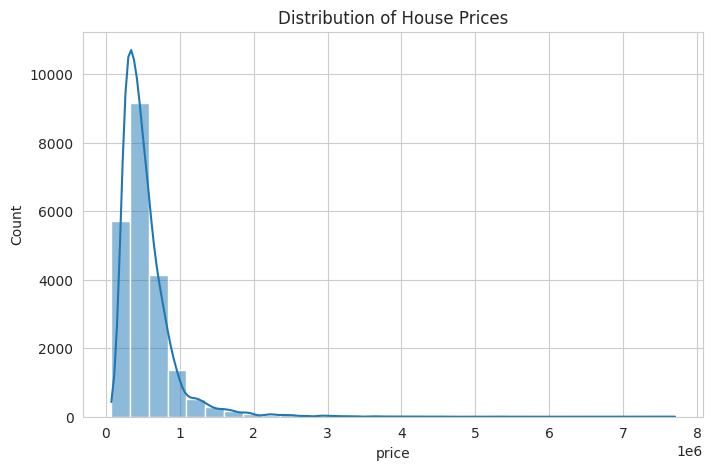

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

* Most houses are priced below 1 million.

* The distribution is right-skewed.

* There are few extremely expensive houses (outliers).

### 📊 2. Bedrooms vs Price

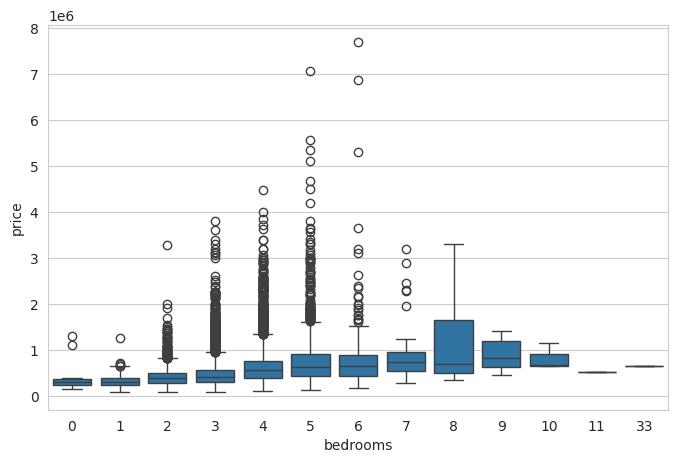

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.show()

* Houses with more bedrooms generally have higher prices.

* However, some houses with many bedrooms do not necessarily have the highest prices.

* There are price outliers in almost every bedroom category.

### 📊 3. Bathrooms vs Price

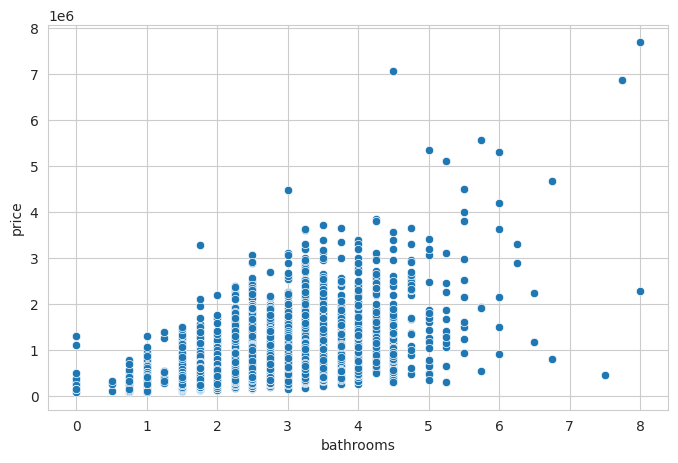

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bathrooms', y='price', data=df)
plt.show()

* There is a positive relationship between bathrooms and price.

* As the number of bathrooms increases, the price tends to increase.

* The relationship is moderately strong.

### 📊 4. Square Foot Living Area vs Price


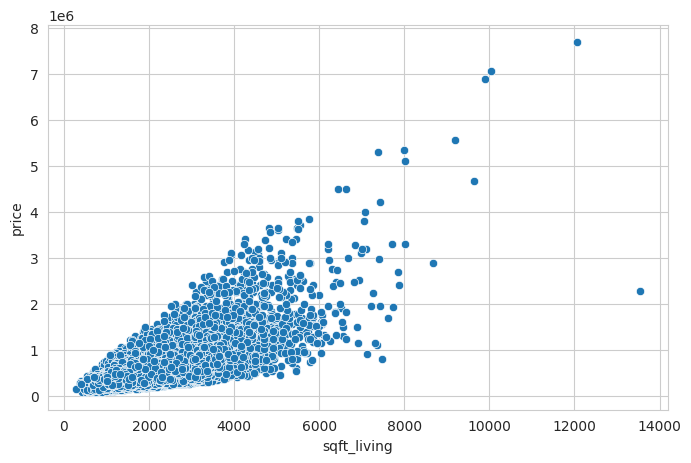

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.show()

* Strong positive correlation between living area and price.

* Larger houses are significantly more expensive.

* This appears to be one of the strongest predictors of price.

### 📊 5. Correlation Heatmap

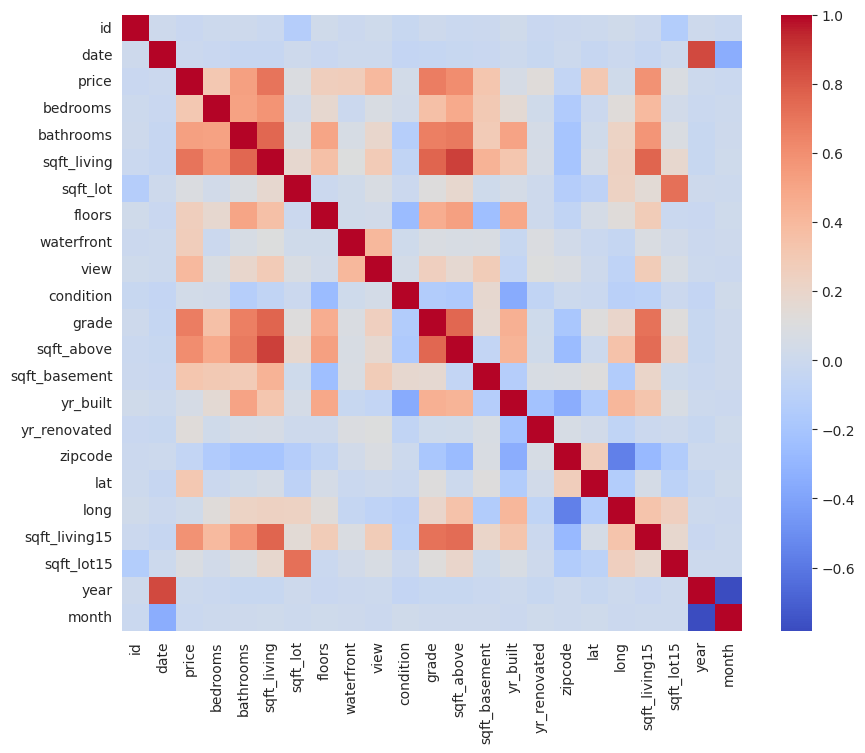

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

* sqft_living has strong correlation with price.

* grade and bathrooms also show strong positive correlation.

* Some variables have very weak correlation and may not strongly affect price.